# Experiment 5: Architecture Ablation (M5)

**Purpose:** Address reviewer concern M5 — "no architectural ablation or cross-architecture
validation." Two sub-concerns are tested:

1. **Untested mechanistic claim** — the paper attributes Model D's graceful degradation to the
   slow LIF group's approximate ω-invariance. Arch-B (no slow group) tests this directly.
2. **Single-architecture benchmark** — all paper results use one architecture. Arch-C
   (single-timescale) provides a cross-architecture baseline showing TEMPO is solvable
   by a simpler design.

| Architecture | Hidden groups | Purpose |
|---|---|---|
| **Arch-A** | fast(42) + medium(43) + slow(43) | Full multi-timescale — benchmark baseline (matches Experiments 2 & 3) |
| **Arch-B** | fast(64) + medium(64), **no slow group** | Ablates ω-invariance claim |
| **Arch-C** | fast(128), single-timescale | Cross-architecture baseline; parameter-matched |

All architectures are trained with stochastic TEMPO v1.1 (σ = 0.838 × T_u, ω ~ U[0.8,1.3],
r ~ U[2.5,4.5]) and evaluated on:
- **Experiment 2 conditions**: intact / shuffled / time-collapsed (temporal irreducibility)
- **Experiment 3 noise sweep**: σ_test ∈ {0.0, 0.2, 0.4, 0.6, 0.84, 1.0, 1.2} × T_u (robustness)

In [1]:
import sys, os, math, time, threading, contextlib
import queue as _q
import concurrent.futures

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import snntorch as snn
from snntorch import surrogate

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from tempo.dataset.generate_dataset import encode_word, MORSE_TABLE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device selection
if torch.cuda.is_available():
    N_CUDA_GPUS = torch.cuda.device_count()
    GPU_DEVICES = [torch.device(f'cuda:{i}') for i in range(N_CUDA_GPUS)]
elif torch.backends.mps.is_available():
    N_CUDA_GPUS = 0
    GPU_DEVICES = [torch.device('mps')]
else:
    N_CUDA_GPUS = 0
    GPU_DEVICES = [torch.device('cpu')]

device = GPU_DEVICES[0]
print(f'Primary device : {device}')
print(f'GPU devices    : {GPU_DEVICES}')

Primary device : cuda:0
GPU devices    : [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2)]


In [2]:
# ── Transmission parameters ───────────────────────────────────────────────
WPM          = 20
T_U          = int(1200 / WPM)          # 60 ms

# ── TEMPO v1.1 stochastic protocol ────────────────────────────────────────
SIGMA_FRAC   = 0.838
T_THRESH     = 2.17
OMEGA_LO, OMEGA_HI = 0.8, 1.3
R_LO,     R_HI     = 2.5, 4.5

# ── Spike tensor ──────────────────────────────────────────────────────────
MAX_T        = 1600

# ── Alphabet ──────────────────────────────────────────────────────────────
LETTERS      = [chr(c) for c in range(ord('A'), ord('Z') + 1)]
N_CLASSES    = len(LETTERS)             # 26

# ── Dataset sizes ─────────────────────────────────────────────────────────
N_TRAIN      = 500
N_TEST       = 100

# ── Training ──────────────────────────────────────────────────────────────
N_EPOCHS     = 100
BATCH_SIZE   = 256
N_SEEDS      = 10
LR_INIT      = 5e-4
LR_MIN       = 1e-5

# ── Noise levels for Experiment 3 conditions ──────────────────────────────
SIGMA_TEST_FRACS = [0.00, 0.20, 0.40, 0.60, 0.84, 1.00, 1.20]
SIGMA_TEST_ABS   = [f * T_U for f in SIGMA_TEST_FRACS]

# ── Architecture IDs ──────────────────────────────────────────────────────
ARCH_IDS = ['A', 'B', 'C']

# ── Checkpointing ─────────────────────────────────────────────────────────
CHECKPOINT_DIR = os.path.join('..', 'checkpoints', 'exp5')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f'T_u        = {T_U} ms')
print(f'Letters    : {" ".join(LETTERS)}')
print(f'Train      : {N_CLASSES} x {N_TRAIN} = {N_CLASSES*N_TRAIN} samples per architecture')
print(f'Test (Exp2): {N_CLASSES} x {N_TEST}  = {N_CLASSES*N_TEST} samples per condition')
print(f'Test (Exp3): {N_CLASSES} x {N_TEST}  = {N_CLASSES*N_TEST} samples per sigma level')
print(f'Epochs     : {N_EPOCHS}  (cosine LR: {LR_INIT} -> {LR_MIN})')
print(f'Seeds      : {N_SEEDS}')
print(f'Total training runs: {len(ARCH_IDS)} archs x {N_SEEDS} seeds = {len(ARCH_IDS)*N_SEEDS}')
print(f'Checkpoint dir : {os.path.abspath(CHECKPOINT_DIR)}')

T_u        = 60 ms
Letters    : A B C D E F G H I J K L M N O P Q R S T U V W X Y Z
Train      : 26 x 500 = 13000 samples per architecture
Test (Exp2): 26 x 100  = 2600 samples per condition
Test (Exp3): 26 x 100  = 2600 samples per sigma level
Epochs     : 100  (cosine LR: 0.0005 -> 1e-05)
Seeds      : 10
Total training runs: 3 archs x 10 seeds = 30
Checkpoint dir : /home/LukeHindman/workspace/tempo/checkpoints/exp5


In [3]:
USE_AMP     = False
USE_COMPILE = False

if N_CUDA_GPUS > 0:
    USE_AMP = True
    print(f'CUDA GPUs detected: {N_CUDA_GPUS}')
    for i in range(N_CUDA_GPUS):
        p = torch.cuda.get_device_properties(i)
        print(f'  cuda:{i}  {p.name}  {p.total_memory//1024**3} GB  '
              f'cc={p.major}.{p.minor}  SMs={p.multi_processor_count}')
else:
    print(f'No CUDA GPUs. Running on: {GPU_DEVICES}')

N_GPU_WORKERS = len(GPU_DEVICES)
print(f'\nN_GPU_WORKERS : {N_GPU_WORKERS}')
print(f'USE_AMP       : {USE_AMP}')

CUDA GPUs detected: 3
  cuda:0  NVIDIA L40S  44 GB  cc=8.9  SMs=142
  cuda:1  NVIDIA L40S  44 GB  cc=8.9  SMs=142
  cuda:2  NVIDIA L40S  44 GB  cc=8.9  SMs=142

N_GPU_WORKERS : 3
USE_AMP       : True


## Architecture Variants

All three architectures share identical `fc1` (2→128) and `fc2` (128→26) weight matrices,
giving approximately equal parameter counts (~3740). The only difference is the number and
configuration of LIF neuron groups in the hidden layer. This ensures accuracy differences
are attributable to timescale structure, not model capacity.

In [4]:
spike_grad = surrogate.fast_sigmoid()


class TempoSNN(nn.Module):
    """Feedforward LIF SNN with configurable hidden-layer neuron groups.

    Parameters
    ----------
    groups : list of (n_neurons, beta_init, threshold)
        Hidden-layer groups. Total hidden size = sum(n for n,_,_ in groups).
    n_in  : int  input channels (default 2: dot, dash)
    n_out : int  output classes  (default 26: A-Z)

    Forward pass is optimised: fc1 and fc2 are dispatched as single matmuls
    across all T time steps, avoiding 1600 per-step kernel launches.
    """

    def __init__(self, groups, n_in=2, n_out=26):
        super().__init__()
        self._sizes = [g[0] for g in groups]
        n_hid       = sum(self._sizes)

        self.fc1 = nn.Linear(n_in, n_hid)
        nn.init.uniform_(self.fc1.weight, -2.0, 2.0)
        nn.init.zeros_(self.fc1.bias)

        self.lifs = nn.ModuleList([
            snn.Leaky(
                beta=b, threshold=thr,
                learn_beta=True,
                reset_mechanism='subtract',
                spike_grad=spike_grad,
            )
            for (_, b, thr) in groups
        ])

        self.fc2  = nn.Linear(n_hid, n_out)
        self.lif2 = snn.Leaky(
            beta=0.95, learn_beta=True,
            reset_mechanism='subtract',
            spike_grad=spike_grad,
        )

    def forward(self, x):
        """x : [T, B, n_in]  →  [B, n_out]  (total output spike counts)"""
        T, B, C = x.shape

        # Single fc1 matmul across all time steps
        cur_all = self.fc1(x.reshape(T * B, C)).reshape(T, B, -1)  # [T, B, n_hid]

        mems     = [lif.init_leaky() for lif in self.lifs]
        spk1_all = []

        for t in range(T):
            cur    = cur_all[t]   # [B, n_hid]
            parts, new_mems, offset = [], [], 0
            for lif, n, mem in zip(self.lifs, self._sizes, mems):
                spk_i, mem_i = lif(cur[:, offset:offset + n], mem)
                parts.append(spk_i)
                new_mems.append(mem_i)
                offset += n
            mems = new_mems
            spk1_all.append(torch.cat(parts, dim=1))   # [B, n_hid]

        # Single fc2 matmul across all time steps
        spk1_seq = torch.stack(spk1_all, dim=0)                          # [T, B, n_hid]
        cur2_all = self.fc2(spk1_seq.reshape(T * B, -1)).reshape(T, B, -1)  # [T, B, n_out]

        mem2, spk2_acc = self.lif2.init_leaky(), None
        for t in range(T):
            spk2, mem2 = self.lif2(cur2_all[t], mem2)
            spk2_acc   = spk2 if spk2_acc is None else spk2_acc + spk2

        return spk2_acc   # [B, n_out]


# ── Architecture configurations ───────────────────────────────────────────
ARCH_CONFIGS = {
    'A': {
        'label'  : 'Arch-A  (F+M+S)',
        'desc'   : 'fast(42) + medium(43) + slow(43)  — benchmark model',
        'groups' : [(42, 0.95, 0.3), (43, 0.99, 0.4), (43, 0.998, 0.5)],
        'color'  : '#2980b9',
        'ls'     : '-',
        'marker' : 'o',
    },
    'B': {
        'label'  : 'Arch-B  (F+M, no slow)',
        'desc'   : 'fast(64) + medium(64)  — ablates ω-invariance claim',
        'groups' : [(64, 0.95, 0.3), (64, 0.99, 0.4)],
        'color'  : '#27ae60',
        'ls'     : '--',
        'marker' : 's',
    },
    'C': {
        'label'  : 'Arch-C  (F only)',
        'desc'   : 'fast(128)  — single-timescale cross-architecture baseline',
        'groups' : [(128, 0.95, 0.3)],
        'color'  : '#e74c3c',
        'ls'     : ':',
        'marker' : '^',
    },
}

# Parameter counts
print(f'{"ID":<4}  {"N_hid":<6}  {"Groups":<8}  {"Params":<8}  Description')
print('-' * 72)
for aid, cfg in ARCH_CONFIGS.items():
    m = TempoSNN(cfg['groups'])
    n = sum(p.numel() for p in m.parameters())
    n_hid = sum(g[0] for g in cfg['groups'])
    print(f'  {aid:<4}  {n_hid:<6}  {len(cfg["groups"]):<8}  {n:<8,}  {cfg["desc"]}')
del m

ID    N_hid   Groups    Params    Description
------------------------------------------------------------------------
  A     128     3         3,742     fast(42) + medium(43) + slow(43)  — benchmark model
  B     128     2         3,741     fast(64) + medium(64)  — ablates ω-invariance claim
  C     128     1         3,740     fast(128)  — single-timescale cross-architecture baseline


## Data Generation and Spike Transforms

In [5]:
def encode_word_sigma(word, t_u, sigma, rng=None, omega=None, r=None):
    """Encode a single letter with explicit jitter sigma (ms).

    Identical internal algorithm to encode_word(jitter=True) from
    tempo.dataset.generate_dataset, but sigma is a direct parameter.

    Args:
        word  : single uppercase letter to encode.
        t_u   : base time unit (ms).
        sigma : jitter std (ms). 0.0 = deterministic element durations.
        rng   : numpy RandomGenerator.
        omega : word-level multiplier. None = sampled U[0.8,1.3].
        r     : dash-to-dot ratio. None = sampled U[2.5,4.5].
    Returns:
        list of (timestamp_ms, channel) — channel 0=dot, 1=dash.
    """
    if rng is None:
        rng = np.random.default_rng()
    t_thresh = T_THRESH * t_u
    _omega   = rng.uniform(OMEGA_LO, OMEGA_HI) if omega is None else float(omega)
    _r       = rng.uniform(R_LO,     R_HI)     if r     is None else float(r)

    t_current = 0.0
    spikes    = []
    chars     = [c for c in word if c in MORSE_TABLE]

    for ci, char in enumerate(chars):
        pattern = MORSE_TABLE[char]
        for ei, element in enumerate(pattern):
            # Mark duration
            t_ideal   = (1.0 if element == '.' else _r) * t_u
            t_noisy   = t_ideal * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0)
            t_final   = max(t_noisy, 0.1 * t_u)
            t_spike   = t_current + t_final
            channel   = 0 if t_final < t_thresh else 1
            spikes.append((t_spike, channel))
            # Intra-character gap after every element
            gap = max(1.0 * t_u * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0),
                      0.1 * t_u)
            t_current = t_spike + gap
        # Inter-character gap supersedes last intra-character gap
        if spikes:
            t_current = spikes[-1][0] + max(
                3.0 * t_u * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0),
                0.1 * t_u)

    # Inter-word gap at end
    # (trailing gap; positions the sequence within MAX_T window)
    return spikes


def make_spike_tensor(spikes, max_t):
    """Convert [(timestamp_ms, channel)] → float32 array [max_t, 2]."""
    tensor = np.zeros((max_t, 2), dtype=np.float32)
    for t, ch in spikes:
        idx = int(round(t))
        if 0 <= idx < max_t:
            tensor[idx, ch] = 1.0
    return tensor


# ── Spike transforms (Experiment 2 conditions) ────────────────────────────

def transform_intact(x):
    """Identity. x: [T, 2] → [T, 2]"""
    return x


def transform_shuffled(x, rng=None):
    """Permute time bins independently per channel. x: [T, 2] → [T, 2]"""
    T = x.shape[0]
    shuffled = x.clone()
    if rng is not None:
        p0 = torch.from_numpy(rng.permutation(T).astype(np.int64))
        p1 = torch.from_numpy(rng.permutation(T).astype(np.int64))
    else:
        p0, p1 = torch.randperm(T), torch.randperm(T)
    shuffled[:, 0] = x[p0, 0]
    shuffled[:, 1] = x[p1, 1]
    return shuffled


def transform_collapsed(x):
    """Replace spike train with count vector replicated over T. x: [T, 2] → [T, 2]"""
    return x.sum(dim=0, keepdim=True).expand_as(x)


def apply_transform(X, name, rng=None):
    """Apply a named transform to batch tensor [N, T, 2] → [N, T, 2]."""
    if name == 'intact':
        return X
    parts = []
    for i in range(len(X)):
        if name == 'collapsed':
            parts.append(transform_collapsed(X[i]))
        elif name == 'shuffled':
            parts.append(transform_shuffled(X[i], rng))
        else:
            raise ValueError(f'Unknown transform: {name}')
    return torch.stack(parts)


print('encode_word_sigma, make_spike_tensor, and spike transforms ready.')

encode_word_sigma, make_spike_tensor, and spike transforms ready.


In [6]:
def generate_train_split(letters, n_per_class, t_u, max_t, rng, label=''):
    """Generate stochastic TEMPO v1.1 training data (sigma=0.838*T_u, stochastic omega, r)."""
    sigma = SIGMA_FRAC * t_u
    X_list, y_list = [], []
    n_total = len(letters) * n_per_class
    for li, letter in enumerate(letters):
        for _ in range(n_per_class):
            spikes = encode_word_sigma(letter, t_u, sigma=sigma, rng=rng)
            X_list.append(make_spike_tensor(spikes, max_t))
            y_list.append(li)
        done = (li + 1) * n_per_class
        print(f'\r  {label}: {done}/{n_total}', end='', flush=True)
    print()
    X = torch.tensor(np.array(X_list), dtype=torch.float32)
    y = torch.tensor(y_list, dtype=torch.long)
    return X, y


def generate_test_split(letters, n_per_class, t_u, max_t, sigma_abs, rng):
    """Generate test data at sigma_abs (ms) with stochastic omega, r.

    Used for both Experiment 2 conditions (sigma_abs = 0.838*T_u)
    and the Experiment 3 noise sweep (sigma_abs varies).
    """
    X_list, y_list = [], []
    for li, letter in enumerate(letters):
        for _ in range(n_per_class):
            spikes = encode_word_sigma(letter, t_u, sigma=sigma_abs, rng=rng)
            X_list.append(make_spike_tensor(spikes, max_t))
            y_list.append(li)
    X = torch.tensor(np.array(X_list), dtype=torch.float32)
    y = torch.tensor(y_list, dtype=torch.long)
    return X, y


print('Data generation functions ready.')

Data generation functions ready.


## Training and Evaluation Functions

In [7]:
_init_lock  = threading.Lock()   # serialises torch.manual_seed + model init
_print_lock = threading.Lock()   # serialises console output


def train_epoch(model, loader, optimizer, device, use_amp=False):
    model.train()
    total_loss = correct = total = 0
    _use_amp = use_amp and device.type == 'cuda'
    amp_ctx  = (torch.autocast('cuda', dtype=torch.bfloat16)
                if _use_amp else contextlib.nullcontext())
    for xb, yb in loader:
        xb = xb.permute(1, 0, 2).to(device, non_blocking=True)  # [T, B, 2]
        yb = yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        with amp_ctx:
            out  = model(xb)
            loss = F.cross_entropy(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.detach().float().item() * len(yb)
        correct    += (out.detach().float().argmax(1) == yb).sum().item()
        total      += len(yb)
    return total_loss / total, correct / total


def train_model(groups, X_train, y_train, n_epochs, batch_size,
                device, seed, label='', use_amp=False):
    """Train a fresh TempoSNN with the given group config. Thread-safe."""
    with _init_lock:
        torch.manual_seed(seed)
        model = TempoSNN(groups).to(device)

    _pin   = device.type == 'cuda'
    loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size, shuffle=True,
        generator=torch.Generator().manual_seed(seed),
        pin_memory=_pin, num_workers=(4 if _pin else 0),
        persistent_workers=_pin,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_INIT)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=LR_MIN
    )
    losses, accs = [], []
    for epoch in range(n_epochs):
        loss, acc = train_epoch(model, loader, optimizer, device, use_amp=use_amp)
        scheduler.step()
        losses.append(loss)
        accs.append(acc)
        if (epoch + 1) % 25 == 0:
            with _print_lock:
                print(f'  [{label} seed={seed}] epoch {epoch+1:3d}  '
                      f'loss={loss:.4f}  acc={acc*100:.1f}%')
    with _print_lock:
        print(f'  [{label}] seed={seed} DONE  train_acc={accs[-1]*100:.1f}%')
    return model, losses, accs


@torch.no_grad()
def evaluate(model, X, y, device, transform='intact', rng=None):
    """Evaluate accuracy under a named spike transform.

    transform : 'intact' | 'shuffled' | 'collapsed'
    """
    model.eval()
    X_t    = apply_transform(X, transform, rng=rng)
    loader = DataLoader(TensorDataset(X_t, y), batch_size=256, shuffle=False,
                        pin_memory=(device.type == 'cuda'), num_workers=0)
    correct = total = 0
    for xb, yb in loader:
        xb = xb.permute(1, 0, 2).to(device, non_blocking=True)
        out = model(xb)
        correct += (out.argmax(1) == yb.to(device, non_blocking=True)).sum().item()
        total   += len(yb)
    return correct / total


print('Training and evaluation functions ready.')

Training and evaluation functions ready.


## Main Experiment — Training

Train all 3 architectures × 10 seeds = 30 models in parallel across available GPUs.
All models use stochastic TEMPO v1.1 training data (equivalent to Model S in Experiment 3).

In [8]:
# ── GPU device pool ───────────────────────────────────────────────────────
_gpool = _q.Queue()
for _i in range(N_GPU_WORKERS):
    _gpool.put(_i)

# all_models[arch_id][seed_index] = result dict
all_models = {aid: [None] * N_SEEDS for aid in ARCH_IDS}

# Tasks: 3 architectures × 10 seeds = 30 total
tasks = [(aid, SEED + si) for si in range(N_SEEDS) for aid in ARCH_IDS]
print(f'Total training tasks : {len(tasks)}  ({len(ARCH_IDS)} archs × {N_SEEDS} seeds)')
print(f'GPU workers          : {N_GPU_WORKERS}')

# Report any existing checkpoints
existing = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pt')]
print(f'Existing checkpoints : {len(existing)} / {len(tasks)}')
print()


def _ckpt_path(arch_id, seed):
    return os.path.join(CHECKPOINT_DIR, f'arch{arch_id}_seed{seed}.pt')


def _train_task(arch_id, seed):
    """Train one architecture variant on any available GPU, with checkpointing.

    If a checkpoint already exists for this (arch_id, seed) pair the model is
    loaded from disk and training is skipped entirely.  Otherwise the model is
    trained as normal and the result is saved to disk before returning.
    """
    gpu_idx = _gpool.get()
    dev     = GPU_DEVICES[gpu_idx]
    try:
        cfg  = ARCH_CONFIGS[arch_id]
        path = _ckpt_path(arch_id, seed)

        if os.path.exists(path):
            with _print_lock:
                print(f'↺ Arch-{arch_id}  seed={seed}  loading checkpoint from disk')
            ckpt  = torch.load(path, map_location=dev, weights_only=False)
            model = TempoSNN(ckpt['groups']).to(dev)
            model.load_state_dict(ckpt['state_dict'])
            losses = ckpt['losses']
            accs   = ckpt['accs']
        else:
            rng = np.random.default_rng(seed)
            with _print_lock:
                print(f'→ Arch-{arch_id}  seed={seed}  training on {dev}')
            X_train, y_train = generate_train_split(
                LETTERS, N_TRAIN, T_U, MAX_T, rng,
                label=f'Arch-{arch_id}/seed={seed}'
            )
            model, losses, accs = train_model(
                cfg['groups'], X_train, y_train,
                N_EPOCHS, BATCH_SIZE, dev, seed,
                label=f'Arch-{arch_id}', use_amp=USE_AMP,
            )
            torch.save({
                'arch_id'   : arch_id,
                'seed'      : seed,
                'groups'    : cfg['groups'],
                'state_dict': model.state_dict(),
                'losses'    : losses,
                'accs'      : accs,
            }, path)
            with _print_lock:
                print(f'  ✓ saved: {os.path.basename(path)}')

        return {
            'arch'     : arch_id,
            'seed'     : seed,
            'seed_idx' : seed - SEED,
            'model'    : model,
            'losses'   : losses,
            'accs'     : accs,
            'device'   : dev,
        }
    finally:
        _gpool.put(gpu_idx)


t0 = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=N_GPU_WORKERS) as executor:
    futures = {executor.submit(_train_task, aid, seed): (aid, seed)
               for aid, seed in tasks}
    for fut in concurrent.futures.as_completed(futures):
        res = fut.result()
        all_models[res['arch']][res['seed_idx']] = res

print(f'\nAll training complete in {time.time()-t0:.0f}s')
for aid in ARCH_IDS:
    train_accs = [all_models[aid][si]['accs'][-1] * 100 for si in range(N_SEEDS)]
    print(f'  Arch-{aid}: mean train_acc = {np.mean(train_accs):.1f}% '
          f'± {np.std(train_accs):.1f}%  (n={N_SEEDS} seeds)')

Total training tasks : 30  (3 archs × 10 seeds)
GPU workers          : 3
Existing checkpoints : 0 / 30

→ Arch-A  seed=42  training on cuda:0
→ Arch-B  seed=42  training on cuda:1
→ Arch-C  seed=42  training on cuda:2
  Arch-B/seed=42: 500/13000

  Arch-C/seed=42: 500/13000

  Arch-C/seed=42: 1000/13000

  Arch-C/seed=42: 1500/13000

  Arch-A/seed=42: 1500/13000

...

  ✓ saved: archC_seed51.pt


  [Arch-B seed=51] epoch 100  loss=1.0755  acc=74.1%
  [Arch-B] seed=51 DONE  train_acc=74.1%


  ✓ saved: archB_seed51.pt


  [Arch-A seed=51] epoch 100  loss=1.0077  acc=74.6%
  [Arch-A] seed=51 DONE  train_acc=74.6%


  ✓ saved: archA_seed51.pt

All training complete in 338263s
  Arch-A: mean train_acc = 74.0% ± 0.8%  (n=10 seeds)
  Arch-B: mean train_acc = 72.4% ± 1.6%  (n=10 seeds)
  Arch-C: mean train_acc = 52.5% ± 1.9%  (n=10 seeds)


In [9]:
# ── Evaluate: Experiment 2 conditions (intact / shuffled / collapsed) ─────
# For each seed and architecture, generate one set of stochastic test data
# (sigma = 0.838*T_u, stochastic omega, r) then apply each transform.
# RNG seed is offset from training seed to guarantee independence.

TRANSFORMS = ['intact', 'shuffled', 'collapsed']

# exp2_results[arch_id][transform] = [acc_seed0, ..., acc_seed9]
exp2_results = {aid: {t: [] for t in TRANSFORMS} for aid in ARCH_IDS}

print('Evaluating Experiment 2 conditions (intact / shuffled / collapsed)...')
sigma_test_exp2 = SIGMA_FRAC * T_U   # same noise level as training

for si in range(N_SEEDS):
    seed     = SEED + si
    rng_test = np.random.default_rng(seed + 10_000)
    X_test, y_test = generate_test_split(
        LETTERS, N_TEST, T_U, MAX_T, sigma_test_exp2, rng_test
    )
    for aid in ARCH_IDS:
        res   = all_models[aid][si]
        model = res['model']
        dev   = res['device']
        for t_name in TRANSFORMS:
            t_rng = np.random.default_rng(seed + 20_000)
            acc   = evaluate(model, X_test, y_test, dev,
                             transform=t_name, rng=t_rng)
            exp2_results[aid][t_name].append(acc)
    print(f'  Seed {seed} done')

print('\nExperiment 2 condition evaluation complete.')

Evaluating Experiment 2 conditions (intact / shuffled / collapsed)...


  Seed 42 done


  Seed 43 done


  Seed 44 done


  Seed 45 done


...

  Seed 47 done


  Seed 48 done


  Seed 49 done


  Seed 50 done


  Seed 51 done

Experiment 2 condition evaluation complete.


In [10]:
# ── Evaluate: Experiment 3 noise sweep ───────────────────────────────────
# For each seed, architecture, and sigma level: generate fresh test data
# with stochastic omega, r. RNG seeds are offset per sigma level.

# sweep_results[arch_id][sigma_idx] = [acc_seed0, ..., acc_seed9]
N_SIGMA      = len(SIGMA_TEST_FRACS)
sweep_results = {aid: [[] for _ in range(N_SIGMA)] for aid in ARCH_IDS}

print('Evaluating Experiment 3 noise sweep...')
print(f'Sigma levels (x T_u): {SIGMA_TEST_FRACS}')
print()

for si in range(N_SEEDS):
    seed = SEED + si
    for sig_idx, (sig_frac, sig_abs) in enumerate(zip(SIGMA_TEST_FRACS, SIGMA_TEST_ABS)):
        rng_test = np.random.default_rng(seed * 100_000 + sig_idx * 1_000 + 50_000)
        X_test, y_test = generate_test_split(
            LETTERS, N_TEST, T_U, MAX_T, sig_abs, rng_test
        )
        for aid in ARCH_IDS:
            res   = all_models[aid][si]
            acc   = evaluate(res['model'], X_test, y_test, res['device'])
            sweep_results[aid][sig_idx].append(acc)
    print(f'  Seed {seed} done')

print('\nNoise sweep evaluation complete.')

Evaluating Experiment 3 noise sweep...
Sigma levels (x T_u): [0.0, 0.2, 0.4, 0.6, 0.84, 1.0, 1.2]



  Seed 42 done


  Seed 43 done


  Seed 44 done


  Seed 45 done


...

  Seed 47 done


  Seed 48 done


  Seed 49 done


  Seed 50 done


  Seed 51 done

Noise sweep evaluation complete.


## Results

In [11]:
# ── Statistical utilities (no scipy dependency) ───────────────────────────

def _betacf(x, a, b, maxit=200, eps=3e-7):
    tiny = 1e-30
    qab, qap, qam = a + b, a + 1.0, a - 1.0
    c, d = 1.0, 1.0 - qab * x / qap
    if abs(d) < tiny: d = tiny
    d, h = 1.0 / d, 1.0 / d
    for m in range(1, maxit + 1):
        m2 = 2 * m
        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d  = 1.0 + aa * d;  d = tiny if abs(d) < tiny else d
        c  = 1.0 + aa / c;  c = tiny if abs(c) < tiny else c
        d  = 1.0 / d;  h *= d * c
        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d  = 1.0 + aa * d;  d = tiny if abs(d) < tiny else d
        c  = 1.0 + aa / c;  c = tiny if abs(c) < tiny else c
        d  = 1.0 / d;  delta = d * c;  h *= delta
        if abs(delta - 1.0) < eps: break
    return h


def _ibeta(x, a, b):
    if x <= 0.0: return 0.0
    if x >= 1.0: return 1.0
    lb = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    bt = math.exp(a * math.log(x) + b * math.log(1.0 - x) - lb)
    if x < (a + 1.0) / (a + b + 2.0):
        return bt * _betacf(x, a, b) / a
    return 1.0 - bt * _betacf(1.0 - x, b, a) / b


def t_sf(t, df):
    """One-tailed P(T > t) for Student t with df degrees of freedom."""
    if t < 0: return 1.0 - t_sf(-t, df)
    return _ibeta(df / (df + t * t), df / 2.0, 0.5) / 2.0


def paired_t_test(a, b):
    """One-tailed paired t-test H1: mean(a) > mean(b). Returns (mu, sd, t, p)."""
    n  = len(a)
    d  = [x - y for x, y in zip(a, b)]
    mu = sum(d) / n
    sd = math.sqrt(sum((v - mu) ** 2 for v in d) / (n - 1)) if n > 1 else 0.0
    se = sd / math.sqrt(n)
    t  = mu / se if se > 1e-12 else (float('inf') if mu > 0 else float('-inf'))
    return mu, sd, t, t_sf(t, n - 1)


# ── Experiment 2 conditions: summary table ────────────────────────────────
CHANCE        = 100.0 / N_CLASSES          # 3.85%
UNIQUE_COUNT  = 100.0 * 7  / N_CLASSES    # 26.9% — unique-count baseline
COUNT_CEILING = 100.0 * 13 / N_CLASSES    # 50.0% — count-only ceiling

print('=' * 70)
print('Experiment 2 Conditions: Architecture Comparison')
print(f'(stochastic test, sigma = {SIGMA_FRAC} x T_u = {SIGMA_FRAC*T_U:.1f} ms)')
print('=' * 70)
print()
print(f'Reference lines:')
print(f'  Chance level        : {CHANCE:.2f}%')
print(f'  Unique-count base   : {UNIQUE_COUNT:.1f}%')
print(f'  Count-only ceiling  : {COUNT_CEILING:.1f}%')
print()

hdr = f'{"Arch":<8}  {"Intact (%)":<16}  {"Shuffled (%)":<16}  {"Collapsed (%)"}'
print(hdr)
print('-' * len(hdr))
for aid in ARCH_IDS:
    row = []
    for cond in TRANSFORMS:
        vals = [v * 100 for v in exp2_results[aid][cond]]
        row.append(f'{np.mean(vals):5.2f} +/- {np.std(vals):4.2f}')
    print(f'  {aid:<6}  {row[0]:<16}  {row[1]:<16}  {row[2]}')
print()

# Temporal irreducibility check
print('Temporal irreducibility (Intact > Shuffled > Collapsed):')
for aid in ARCH_IDS:
    i_m = np.mean([v*100 for v in exp2_results[aid]['intact']])
    s_m = np.mean([v*100 for v in exp2_results[aid]['shuffled']])
    c_m = np.mean([v*100 for v in exp2_results[aid]['collapsed']])
    ok  = i_m > s_m > c_m
    print(f'  Arch-{aid}: {i_m:.1f}% > {s_m:.1f}% > {c_m:.1f}%  {"PASS" if ok else "FAIL"}')
print()

# Paired t-tests: Arch-A intact vs Arch-B and Arch-C
print('Paired t-tests: Arch-A intact > Arch-B/C intact  (one-tailed, n=10 seeds):')
a_vals = [v*100 for v in exp2_results['A']['intact']]
for cmp_aid in ['B', 'C']:
    cmp_vals = [v*100 for v in exp2_results[cmp_aid]['intact']]
    mu, sd, t, p = paired_t_test(a_vals, cmp_vals)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  A vs {cmp_aid}: delta={mu:+.2f}pp  t({N_SEEDS-1})={t:.3f}  p={p:.4f}  {sig}')

Experiment 2 Conditions: Architecture Comparison
(stochastic test, sigma = 0.838 x T_u = 50.3 ms)

Reference lines:
  Chance level        : 3.85%
  Unique-count base   : 26.9%
  Count-only ceiling  : 50.0%

Arch      Intact (%)        Shuffled (%)      Collapsed (%)
-----------------------------------------------------------
  A       74.07 +/- 0.88    26.34 +/- 1.07     3.85 +/- 0.00
  B       72.47 +/- 1.15    28.50 +/- 1.57     3.85 +/- 0.00
  C       51.58 +/- 2.20    32.63 +/- 2.37     3.88 +/- 0.09

Temporal irreducibility (Intact > Shuffled > Collapsed):
  Arch-A: 74.1% > 26.3% > 3.8%  PASS
  Arch-B: 72.5% > 28.5% > 3.8%  PASS
  Arch-C: 51.6% > 32.6% > 3.9%  PASS

Paired t-tests: Arch-A intact > Arch-B/C intact  (one-tailed, n=10 seeds):
  A vs B: delta=+1.59pp  t(9)=5.778  p=0.0001  ***
  A vs C: delta=+22.48pp  t(9)=33.170  p=0.0000  ***


In [12]:
# ── Experiment 3 noise sweep: summary table ───────────────────────────────
print('=' * 70)
print('Experiment 3 Noise Sweep: Architecture Comparison')
print('(stochastic omega, r at all test levels; mean +/- std, n=10 seeds)')
print('=' * 70)
print()

# Header
cols = ['sigma/T_u'] + [f'Arch-{aid} (%)' for aid in ARCH_IDS]
print(f'{cols[0]:<12}  {cols[1]:<18}  {cols[2]:<18}  {cols[3]}')
print('-' * 72)

sweep_means = {aid: [] for aid in ARCH_IDS}
sweep_stds  = {aid: [] for aid in ARCH_IDS}

for sig_idx, sig_frac in enumerate(SIGMA_TEST_FRACS):
    row_parts = [f'  {sig_frac:.2f}']
    for aid in ARCH_IDS:
        vals = [v * 100 for v in sweep_results[aid][sig_idx]]
        m, s = np.mean(vals), np.std(vals)
        sweep_means[aid].append(m)
        sweep_stds[aid].append(s)
        row_parts.append(f'{m:5.1f} +/- {s:4.1f}')
    print(f'{row_parts[0]:<12}  {row_parts[1]:<18}  {row_parts[2]:<18}  {row_parts[3]}')

print()

# Pairwise advantage of Arch-A over Arch-B and Arch-C at each sigma level
print('Arch-A advantage over Arch-B (delta pp, positive = A better):')
for sig_idx, sf in enumerate(SIGMA_TEST_FRACS):
    a_vals  = [v*100 for v in sweep_results['A'][sig_idx]]
    b_vals  = [v*100 for v in sweep_results['B'][sig_idx]]
    mu, sd, t, p = paired_t_test(a_vals, b_vals)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  sigma={sf:.2f}: delta={mu:+.2f}pp  t={t:.2f}  p={p:.4f}  {sig}')
print()

print('Arch-A advantage over Arch-C (delta pp, positive = A better):')
for sig_idx, sf in enumerate(SIGMA_TEST_FRACS):
    a_vals  = [v*100 for v in sweep_results['A'][sig_idx]]
    c_vals  = [v*100 for v in sweep_results['C'][sig_idx]]
    mu, sd, t, p = paired_t_test(a_vals, c_vals)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  sigma={sf:.2f}: delta={mu:+.2f}pp  t={t:.2f}  p={p:.4f}  {sig}')

Experiment 3 Noise Sweep: Architecture Comparison
(stochastic omega, r at all test levels; mean +/- std, n=10 seeds)

sigma/T_u     Arch-A (%)          Arch-B (%)          Arch-C (%)
------------------------------------------------------------------------
  0.00         98.8 +/-  0.5       97.6 +/-  1.1       67.7 +/-  4.1
  0.20         97.5 +/-  0.5       96.0 +/-  1.1       66.5 +/-  3.5
  0.40         94.0 +/-  0.4       92.3 +/-  1.0       64.0 +/-  3.1
  0.60         86.4 +/-  0.6       84.4 +/-  1.4       59.1 +/-  3.0
  0.84         74.1 +/-  0.7       72.2 +/-  0.7       52.0 +/-  2.5
  1.00         66.0 +/-  0.6       64.6 +/-  1.0       47.5 +/-  2.2
  1.20         58.5 +/-  0.9       57.3 +/-  1.1       42.8 +/-  1.6

Arch-A advantage over Arch-B (delta pp, positive = A better):
  sigma=0.00: delta=+1.15pp  t=4.32  p=0.0010  ***
  sigma=0.20: delta=+1.56pp  t=4.77  p=0.0005  ***
  sigma=0.40: delta=+1.73pp  t=4.99  p=0.0004  ***
  sigma=0.60: delta=+1.95pp  t=5.85  p=0.0001

## Figures

Figure saved to: ../figures/exp5_architecture_ablation.pdf


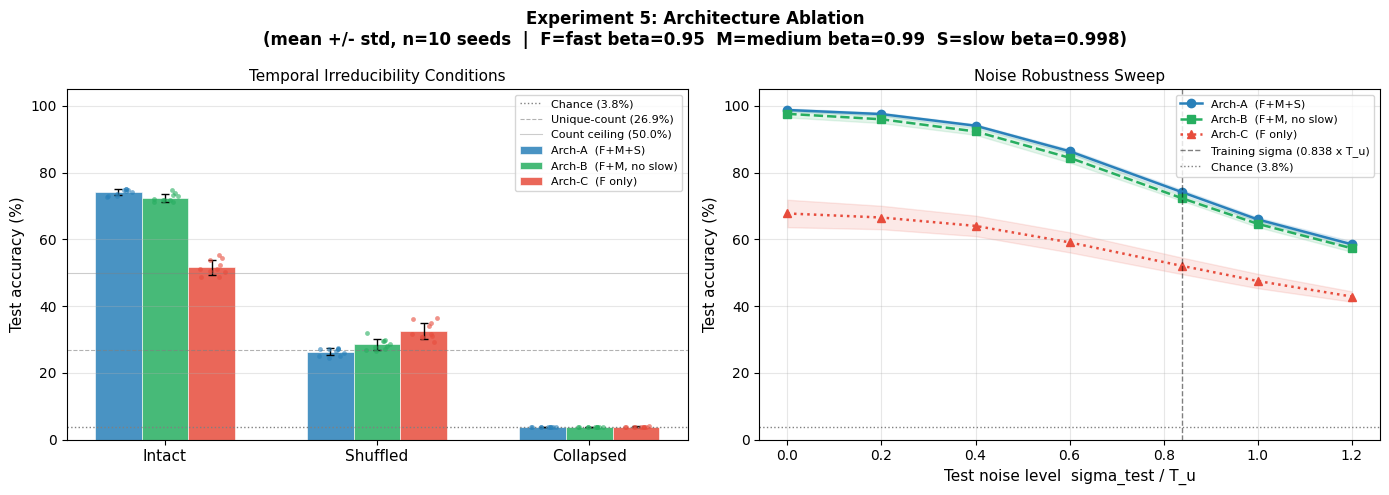

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Experiment 5: Architecture Ablation\n'
    f'(mean +/- std, n={N_SEEDS} seeds  |  '
    f'F=fast beta=0.95  M=medium beta=0.99  S=slow beta=0.998)',
    fontsize=12, fontweight='bold'
)

# ── Left panel: Experiment 2 conditions ──────────────────────────────────
ax = axes[0]
cond_labels = {'intact': 'Intact', 'shuffled': 'Shuffled', 'collapsed': 'Collapsed'}
n_conds     = len(TRANSFORMS)
n_archs     = len(ARCH_IDS)
bar_w       = 0.22
offsets     = np.linspace(-(n_archs-1)/2 * bar_w, (n_archs-1)/2 * bar_w, n_archs)
x_centers   = np.arange(n_conds)

for ai, aid in enumerate(ARCH_IDS):
    cfg = ARCH_CONFIGS[aid]
    for ci, cond in enumerate(TRANSFORMS):
        vals = [v * 100 for v in exp2_results[aid][cond]]
        m, s = np.mean(vals), np.std(vals)
        xpos = x_centers[ci] + offsets[ai]
        ax.bar(xpos, m, width=bar_w, color=cfg['color'], alpha=0.85,
               label=cfg['label'] if ci == 0 else None,
               edgecolor='white', linewidth=0.5)
        ax.errorbar(xpos, m, yerr=s, fmt='none', color='black',
                    capsize=3, linewidth=1.0)
        # Per-seed dots
        jitter = np.random.default_rng(42).uniform(-bar_w*0.3, bar_w*0.3, len(vals))
        ax.scatter(xpos + jitter, vals, color=cfg['color'], s=12,
                   alpha=0.6, zorder=5, linewidths=0)

# Reference lines
ax.axhline(CHANCE,        color='gray',   linestyle=':',  linewidth=1.0,
           label=f'Chance ({CHANCE:.1f}%)')
ax.axhline(UNIQUE_COUNT,  color='gray',   linestyle='--', linewidth=0.8, alpha=0.6,
           label=f'Unique-count ({UNIQUE_COUNT:.1f}%)')
ax.axhline(COUNT_CEILING, color='gray',   linestyle='-',  linewidth=0.8, alpha=0.4,
           label=f'Count ceiling ({COUNT_CEILING:.1f}%)')

ax.set_xticks(x_centers)
ax.set_xticklabels([cond_labels[c] for c in TRANSFORMS], fontsize=11)
ax.set_ylabel('Test accuracy (%)', fontsize=11)
ax.set_title('Temporal Irreducibility Conditions', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

# ── Right panel: Experiment 3 noise sweep ────────────────────────────────
ax = axes[1]
x_sigma = np.array(SIGMA_TEST_FRACS)

for aid in ARCH_IDS:
    cfg = ARCH_CONFIGS[aid]
    m   = np.array(sweep_means[aid])
    s   = np.array(sweep_stds[aid])
    ax.plot(x_sigma, m, color=cfg['color'], linestyle=cfg['ls'],
            marker=cfg['marker'], markersize=6, linewidth=1.8,
            label=cfg['label'])
    ax.fill_between(x_sigma, m - s, m + s, color=cfg['color'], alpha=0.12)

# Reference lines
ax.axvline(SIGMA_FRAC, color='black', linestyle='--', linewidth=1.0, alpha=0.5,
           label=f'Training sigma ({SIGMA_FRAC} x T_u)')
ax.axhline(CHANCE, color='gray', linestyle=':', linewidth=1.0,
           label=f'Chance ({CHANCE:.1f}%)')

ax.set_xlabel('Test noise level  sigma_test / T_u', fontsize=11)
ax.set_ylabel('Test accuracy (%)', fontsize=11)
ax.set_title('Noise Robustness Sweep', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)

plt.tight_layout()

fig_path = os.path.join('..', 'figures', 'exp5_architecture_ablation.pdf')
fig.savefig(fig_path, bbox_inches='tight')
print(f'Figure saved to: {fig_path}')
plt.show()

## Summary and Success Criteria

In [14]:
print('=' * 70)
print('Experiment 5: Architecture Ablation — Summary')
print('=' * 70)
print()

# Compute key numbers
results_summary = {}
for aid in ARCH_IDS:
    i_vals = [v*100 for v in exp2_results[aid]['intact']]
    s_vals = [v*100 for v in exp2_results[aid]['shuffled']]
    c_vals = [v*100 for v in exp2_results[aid]['collapsed']]
    # Noise robustness at training sigma (0.84 x T_u)
    idx_084 = SIGMA_TEST_FRACS.index(0.84)
    r_vals  = [v*100 for v in sweep_results[aid][idx_084]]
    results_summary[aid] = {
        'intact'    : (np.mean(i_vals), np.std(i_vals)),
        'shuffled'  : (np.mean(s_vals), np.std(s_vals)),
        'collapsed' : (np.mean(c_vals), np.std(c_vals)),
        'robust_084': (np.mean(r_vals), np.std(r_vals)),
    }

print(f'{"Architecture":<32}  {"Intact":<14}  {"Shuffled":<14}  {"At sigma=0.84"}')
print('-' * 80)
for aid in ARCH_IDS:
    r = results_summary[aid]
    print(f'  {ARCH_CONFIGS[aid]["desc"]:<30}  '
          f'{r["intact"][0]:5.1f}+/-{r["intact"][1]:4.1f}  '
          f'{r["shuffled"][0]:5.1f}+/-{r["shuffled"][1]:4.1f}  '
          f'{r["robust_084"][0]:5.1f}+/-{r["robust_084"][1]:4.1f}')
print()

# Success criteria
print('Success Criteria:')

# 1. All architectures show temporal irreducibility
all_irreducible = all(
    np.mean([v*100 for v in exp2_results[aid]['intact']]) >
    np.mean([v*100 for v in exp2_results[aid]['shuffled']]) >
    np.mean([v*100 for v in exp2_results[aid]['collapsed']])
    for aid in ARCH_IDS
)
print(f'  Temporal irreducibility for all architectures : {"PASS" if all_irreducible else "FAIL"}')

# 2. Arch-C intact > count-only ceiling (task is solvable)
c_intact = np.mean([v*100 for v in exp2_results['C']['intact']])
solvable = c_intact > COUNT_CEILING
print(f'  Arch-C intact ({c_intact:.1f}%) > count ceiling ({COUNT_CEILING:.1f}%) : '
      f'{"PASS" if solvable else "FAIL"}')

# 3. Arch-A intact >= 70% (consistent with Experiments 2 and 3)
a_intact = np.mean([v*100 for v in exp2_results['A']['intact']])
baseline_ok = a_intact >= 70.0
print(f'  Arch-A intact ({a_intact:.1f}%) >= 70% (Exp 2/3 consistency) : '
      f'{"PASS" if baseline_ok else "FAIL"}')

# 4. Arch-A noise robustness at sigma=0.84 > Arch-C
a_084 = np.mean([v*100 for v in sweep_results['A'][idx_084]])
c_084 = np.mean([v*100 for v in sweep_results['C'][idx_084]])
robust_ok = a_084 > c_084
print(f'  Arch-A at sigma=0.84 ({a_084:.1f}%) > Arch-C ({c_084:.1f}%) : '
      f'{"PASS" if robust_ok else "FAIL"}')

# 5. omega-invariance: Arch-A > Arch-B degradation pattern?
a_084b = np.mean([v*100 for v in sweep_results['A'][idx_084]])
b_084  = np.mean([v*100 for v in sweep_results['B'][idx_084]])
omega_inv = a_084b > b_084
print(f'  Arch-A at sigma=0.84 ({a_084b:.1f}%) > Arch-B ({b_084:.1f}%)  '
      f'(omega-inv. supported) : {"PASS" if omega_inv else "NOT SUPPORTED"}')

print()
print('Figure output : ../figures/exp5_architecture_ablation.pdf')

Experiment 5: Architecture Ablation — Summary

Architecture                      Intact          Shuffled        At sigma=0.84
--------------------------------------------------------------------------------
  fast(42) + medium(43) + slow(43)  — benchmark model   74.1+/- 0.9   26.3+/- 1.1   74.1+/- 0.7
  fast(64) + medium(64)  — ablates ω-invariance claim   72.5+/- 1.1   28.5+/- 1.6   72.2+/- 0.7
  fast(128)  — single-timescale cross-architecture baseline   51.6+/- 2.2   32.6+/- 2.4   52.0+/- 2.5

Success Criteria:
  Temporal irreducibility for all architectures : PASS
  Arch-C intact (51.6%) > count ceiling (50.0%) : PASS
  Arch-A intact (74.1%) >= 70% (Exp 2/3 consistency) : PASS
  Arch-A at sigma=0.84 (74.1%) > Arch-C (52.0%) : PASS
  Arch-A at sigma=0.84 (74.1%) > Arch-B (72.2%)  (omega-inv. supported) : PASS

Figure output : ../figures/exp5_architecture_ablation.pdf
